# Tunneling and contact scanning probe spectroscopy

A scanning-tunneling-microscope tip is modelled by `LocalProbe` as a weakly coupled lead whose
coupling strength `lp.T` plays the role of tip-sample distance: small `T` is the tunneling
regime (conductance set by the sample's local density of states, exponentially small in
distance), while `T` close to 1 is the contact regime (conductance saturating at a
coupling-independent value). Left panel: in the tunneling limit, `dIdV(E)` closely tracks the
sample's own local DOS `get_dos(E)` -- the basic principle of STM spectroscopy. Right panel:
sweeping the coupling at fixed bias traces out the tunneling-to-contact crossover directly.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

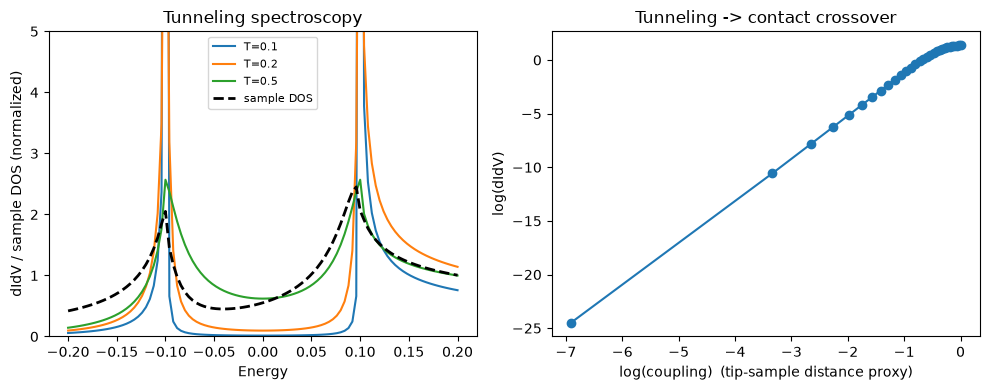

In [2]:
from pyqula.heterostructures import LocalProbe

# --- tunneling spectroscopy: dIdV tracks the sample's local DOS ---
g = geometry.chain()
h = g.get_hamiltonian()
h.add_onsite(2.0)
h.add_swave(0.1)
lp = LocalProbe(h) ; lp.delta = 1e-3
es = np.linspace(-0.2,0.2,101)

fig,axs = plt.subplots(1,2,figsize=(10,4))
for T in [0.1,0.2,0.5]:
    lp.T = T
    ts = np.array([lp.didv(energy=e) for e in es]) ; ts /= np.mean(ts)
    axs[0].plot(es,ts,label=f"T={T}")
ds = np.array([lp.get_dos(energy=e) for e in es]) ; ds /= np.mean(ds)
axs[0].plot(es,ds,"k--",label="sample DOS",linewidth=2)
axs[0].set_xlabel("Energy") ; axs[0].set_ylabel("dIdV / sample DOS (normalized)")
axs[0].set_ylim([0,5]) ; axs[0].legend(fontsize=8)
axs[0].set_title("Tunneling spectroscopy")

# --- tunneling-to-contact crossover: conductance vs coupling at fixed bias ---
g2 = geometry.square_ribbon(1)
h2 = g2.get_hamiltonian()
h2.shift_fermi(1.0)
h1n = h2.copy() ; h1n.add_swave(.0)
h2sc = h2.copy() ; h2sc.add_swave(.1)
ht = heterostructures.build(h2sc,h1n)
ht.delta = 1e-12
ts_coupling = np.linspace(1e-3,1.0,30)
gs = []
e = 0.07
for t in ts_coupling:
    ht.scale_rc = t
    gs.append(ht.didv(energy=e))
axs[1].plot(np.log(ts_coupling),np.log(gs),marker="o")
axs[1].set_xlabel("log(coupling)  (tip-sample distance proxy)")
axs[1].set_ylabel("log(dIdV)")
axs[1].set_title("Tunneling -> contact crossover")
plt.tight_layout()
plt.show()